In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

# 5) Processus de Poisson 

## 5.1) Simuler une trajectoire 

Il est possible de simuler un processus de Poisson de deux façons différentes : simuler ses $n$ premiers sauts ou simuler le processus jusqu'à l'instant $t$. 

Commençons par la première option. Pour faire cela, on utilise la propriété suivante : si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors on peut écrire $N_t$ sous la forme 
$$N_t = \sum_{n=1}^{+\infty} 1_{T_n \le t},$$
où la suite $(T_n)_{n \ge 1}$ de temps de sauts du processus est donnée par : 
$$T_n= \sum_{k=1}^n \tau_k,$$
où les $(\tau_k)_{k \ge 1}$ (durées inter-sauts) suivent des lois exponentielles de paramètre $\lambda$. 

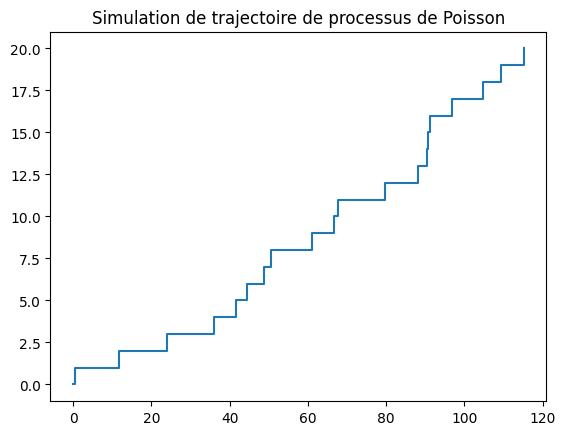

In [4]:
def trajectoire_Poisson(n,l): 
    X=scipy.stats.expon.rvs(loc=0,scale=1/l,size=n)
    T=np.array([0]+list(np.cumsum(X)))
    N=np.arange(n+1)
    plt.plot(T,N,drawstyle='steps-post')
    plt.title('Simulation de trajectoire de processus de Poisson')
    plt.show()

trajectoire_Poisson(20,1/5)
# Pour vérifier que le résultat est cohérent, il faut regarder en moyenne la fréquence des sauts 
# (ici il faut environ 100 unités de temps pour faire 20 sauts, ça paraît ok)

Voyons maintenant comment simuler une trajectoire du processus jusqu'à un instant $t$. Pour faire cela, on utilise les deux propriétés suivantes : si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors pour tout $t>0$, la variable $N_t$ suit une loi de Poisson de paramètre $\lambda t$, et sachant $N_t=n$, la loi du $n$-uplet $(T_1,\dots,T_n)$ coincide avec celle d'un $n$-échantillon ordonné de variables aléatoires iid de loi uniforme sur $[0,t]$. 

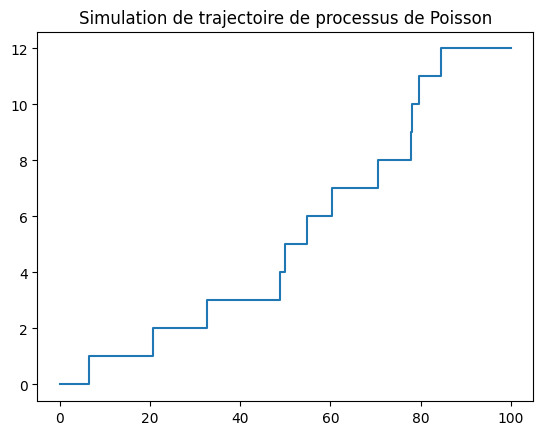

In [6]:
def trajectoire_Poisson3(t,l): 
    n=scipy.stats.poisson.rvs(mu=l*t)
    U=scipy.stats.uniform.rvs(loc=0,scale=t,size=n)
    T=[0]+list(np.sort(U))+[t]
    N=list(np.arange(n+1))+[n]
    plt.plot(T,N,drawstyle='steps-post')
    plt.title('Simulation de trajectoire de processus de Poisson')
    plt.show()

trajectoire_Poisson3(100,1/5)
# De même ici, on vérifie qu'on fait en moyenne 20 sauts en 100 unités de temps, cela paraît cohérent. 

## 5.2) Estimation du paramètre 

Pour estimer le paramètre d'un processus de Poisson, on a de nouveau deux points de vue : soit on connaît le $n$-ième temps de sauts du processus, soit on connaît le processus à un certain instant $t$.

Voyons tout d'abord le premier cadre : on connaît le $n$-ième temps de sauts du processus. La loi des grands nombres et le théorème central limite classiques appliqués aux variables $(T_n)_{n \ge 1}$ nous donne le résultat suivant. 

Si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors on a les convergences suivantes : 
$$\frac{n}{T_n} \xrightarrow[n \to \infty]{\text{p.s.}} \lambda $$
et 
$$ \sqrt n \left ( \lambda \frac {T_n}{n} - 1 \right ) \xrightarrow[n \to \infty]{\mathcal L }\mathcal{N}(0,1).$$

Illustrons ces deux convergences ! 

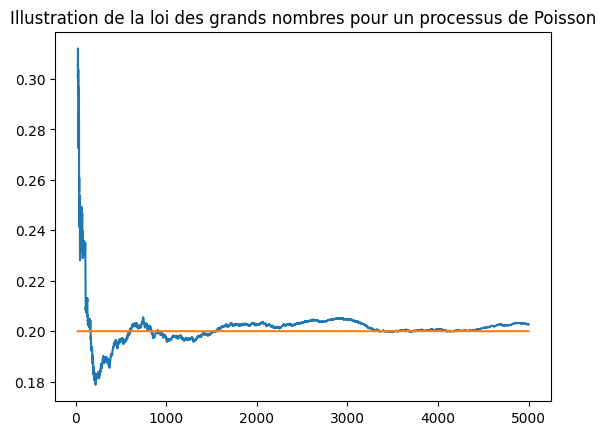

In [8]:
def illustration_cv_ps_n(l,n): 
    X=scipy.stats.expon.rvs(loc=0,scale=1/l,size=n)
    T=np.array([0]+list(np.cumsum(X)))
    N=np.arange(20,n+1)
    E=[i/T[i] for i in N]
    L=l*np.ones(len(E))
    plt.plot(N,E,label='estimateur')
    plt.plot(N,L,label='valeur théorique')
    plt.title('Illustration de la loi des grands nombres pour un processus de Poisson')
    plt.show()

illustration_cv_ps_n(1/5,5000)

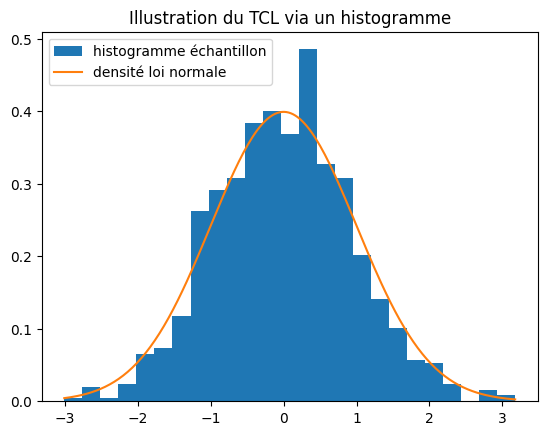

In [9]:
def illustration_cv_loi_n(n,l,N):
    H=[]
    for _ in range (N):
        X=scipy.stats.expon.rvs(loc=0,scale=1/l,size=n)
        T=np.array([0]+list(np.cumsum(X)))
        e=T[-1]/n
        h=np.sqrt(n)*(l*e-1)
        H.append(h)
    X=np.linspace(min(H),max(H),200)
    Y=stats.norm.pdf(X)
    plt.hist(H,25,density='True', label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration du TCL via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_n(1000,1/5,1000)

A partir du TCL, on peut obtenir un intervalle de confiance (asymptotique) de niveau de confiance $\alpha$ pour $\lambda$ : 
$$I_\alpha := \left [\widehat{\lambda_n}\left( 1 - \frac{q_{1 - \alpha/2}}{\sqrt n}\right ), \widehat{\lambda_n}\left( 1 + \frac{q_{1 - \alpha/2}}{\sqrt n} \right) \right ], $$
avec $\widehat{\lambda_n}:= \frac{n}{T_n}$ est l'estimateur de $\lambda$ donné par la loi des grands nombres, et où $q_{1 - \alpha/2}$ est le quantile d'ordre $1 -\frac{\alpha}{2}$ d'une loi normale centrée réduite.  
Illustrons cela ! 

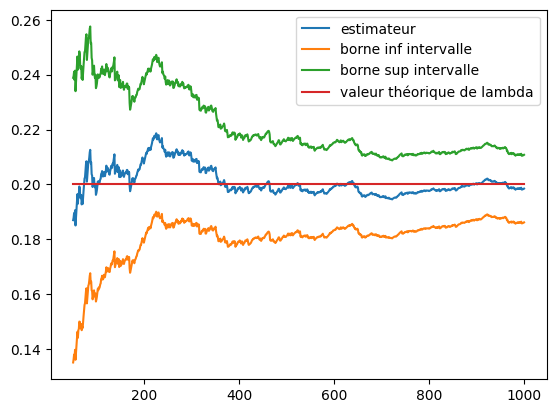

In [11]:
def illustration_intervalle_n(n,l,alpha):
    X=scipy.stats.expon.rvs(loc=0,scale=1/l,size=n)
    T=np.array([0]+list(np.cumsum(X)))
    N=np.arange(n+1)
    E=[]
    I_inf=[]
    I_sup=[]
    q= stats.norm.ppf(1-alpha/2,loc=0,scale=1)
    for k in N[50:] :
        e=k/T[k]
        E.append(e)
        i_inf=e*(1-q/np.sqrt(k))
        I_inf.append(i_inf)
        i_sup=e*(1+q/np.sqrt(k))
        I_sup.append(i_sup)
    L=l*np.ones(len(N[50:]))
    plt.plot(N[50:],E,label='estimateur')
    plt.plot(N[50:],I_inf,label='borne inf intervalle')
    plt.plot(N[50:],I_sup,label='borne sup intervalle')
    plt.plot(N[50:],L,label='valeur théorique de lambda')
    plt.legend()
    plt.show()

illustration_intervalle_n(1000,1/5,0.05)

Voyons maintenant le deuxième cadre : on suppose désormais que l'on observe le processus à un certain instant $t$. En travaillant sur les accroissement de $(N_t)_{t \ge 0}$, on obtient les théorèmes suivants. 

Si $(N_t)_{t \ge 0}$ est un processus de Poisson de paramètre $\lambda$, alors on a les convergences suivantes : 
$$\frac{N_t}{t} \xrightarrow[t \to \infty]{\text{p.s.}} \lambda $$
et 
$$ \sqrt{\frac{t}{\lambda}} \left ( \frac {N_t}{t} - \lambda \right ) \xrightarrow[t \to \infty]{\mathcal L }\mathcal{N}(0,1).$$

En combinant ces deux convergences avec le lemme de Slutsky, on obtient, en notant $\widehat{\lambda_t}:=\frac{N_t}{t}$ (estimateur de $\lambda$) : 
$$\sqrt{\frac{t}{\widehat{\lambda_t}}} \left ( \widehat{\lambda_t} - \lambda \right) \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1) .$$
Illustrons ces deux convergences ! 

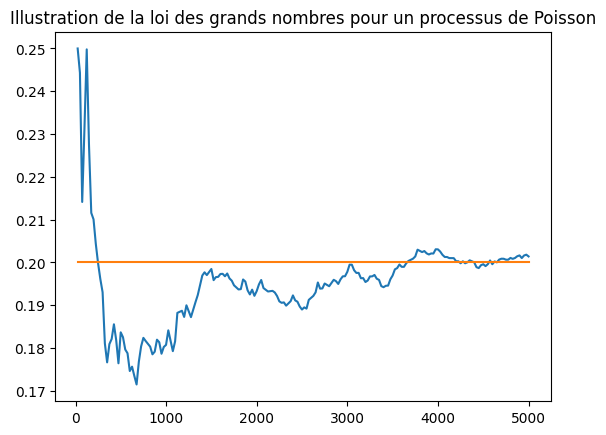

In [14]:
def illustration_cv_ps_t(l,t): 
    k=scipy.stats.poisson.rvs(mu=l*t)
    U=scipy.stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    temps=np.linspace(20,t,200)
    E=[]
    for s in temps : 
        e=np.sum([T<=s])/s
        E.append(e)
    L=l*np.ones(len(temps))
    plt.plot(temps,E,label='estimateur')
    plt.plot(temps,L,label='valeur théorique')
    plt.title('Illustration de la loi des grands nombres pour un processus de Poisson')
    plt.show()

illustration_cv_ps_t(1/5,5000)

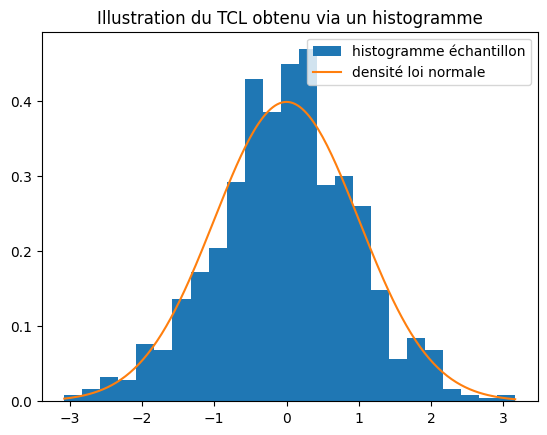

In [15]:
def illustration_cv_loi_t(t,l,N):
    H=[]
    for _ in range (N):
        k=scipy.stats.poisson.rvs(mu=l*t) # seulement besoin de Nt
        e=k/t
        h=np.sqrt(t/e)*(e-l)
        H.append(h)
    X=np.linspace(min(H),max(H),200)
    Y=stats.norm.pdf(X)
    plt.hist(H,25,density='True', label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration du TCL obtenu via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_t(1000,1/5,1000)

On peut obtenir à partir de la dernière convergence en loi un intervalle de confiance (asymptotique) de niveau de confiance $\alpha$ pour $\lambda$ : 
$$ I_\alpha := \left [  \widehat{\lambda_t} -  q_{1 - \alpha/2}\sqrt{\frac{\widehat{\lambda_t}}{t}} , \widehat{\lambda_t} + q_{1 - \alpha/2} \sqrt{\frac{\widehat{\lambda_t}}{t}}  \right ], $$
avec $\widehat{\lambda_t}:= \frac{N_t}{t}$ est un estimateur de $\lambda$, et où $q_{1 - \alpha/2}$ est le quantile d'ordre $1 -\alpha /2$ d'une loi normale centrée réduite. Illustrons de nouveau cet intervalle ! 

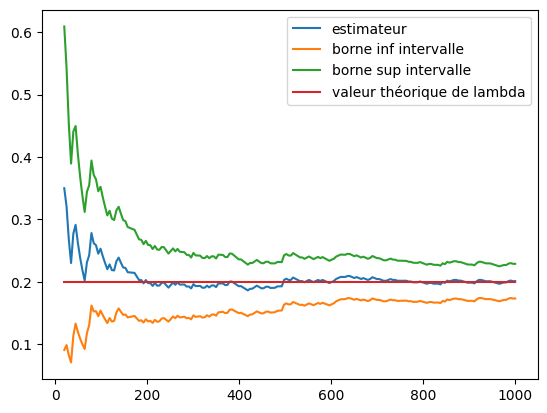

In [17]:
def illustration_intervalle_t(t,l,alpha):
    k=scipy.stats.poisson.rvs(mu=l*t)
    U=scipy.stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    temps=np.linspace(20,t,200)
    E=[]
    I_inf=[]
    I_sup=[]
    q= stats.norm.ppf(1-alpha/2,loc=0,scale=1)
    for s in temps :
        e=np.sum([T<=s])/s
        E.append(e)
        i_inf=e-np.sqrt(e/s)*q
        I_inf.append(i_inf)
        i_sup=e+np.sqrt(e/s)*q
        I_sup.append(i_sup)
    L=l*np.ones(len(temps))
    plt.plot(temps,E,label='estimateur')
    plt.plot(temps,I_inf,label='borne inf intervalle')
    plt.plot(temps,I_sup,label='borne sup intervalle')
    plt.plot(temps,L,label='valeur théorique de lambda')
    plt.legend()
    plt.show()

illustration_intervalle_t(1000,1/5,0.05)

## 5.3) Processus de Poisson composé

Une extension assez simple du processus de Poisson est le processus de Poisson composé. Ses propriétés sont proches du processus de Poisson classique, et les simulations ne sont pas beaucoup plus compliquées ! 

Soit $(\tau_k)_{k \ge 1}$ une suite de variables iid de loi exponentielle de paramètre $\lambda$ et soit $(Y_n)_{n \ge 1}$ une suite de variables iid de loi $\nu$ indépendante de la suite $(\tau_k)_{k \ge 1}$. On définit 
$$T_n = \sum_{k=1}^n \tau_k.$$ 
On appelle processus de Poisson composé d'intensité $\lambda$ et de loi de saut $\nu$ le processus $(X_t)_{t \ge 0}$ partant de 0 et défini par 
$$X_t := \sum_{n=1}^{+\infty } Y_n 1_{T_n \le t}.$$

On remarque que l'on peut réécrire $X_t$ sous la forme : 
$$X_t := \sum_{n=1}^{N_t } Y_n,$$
où 
$$N_t = \sum_{n=1}^{+\infty} 1_{T_n \le t}$$
est un processus de Poisson d'intensité $\lambda$. 

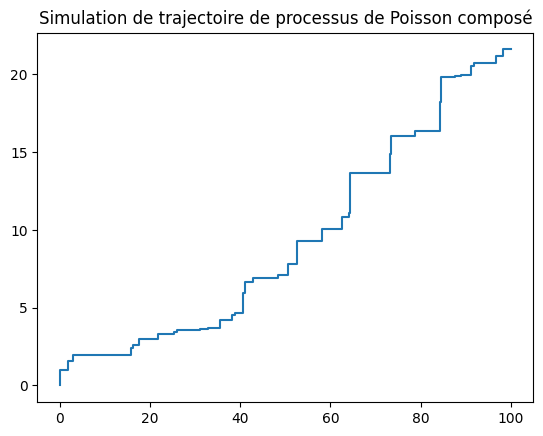

In [20]:
def trajectoire_Poisson_composé_expo(t,l,m,b): # simule une trajectoire de pP composé de loi de saut exponentielle jusqu'à l'étape t
    k=scipy.stats.poisson.rvs(mu=l*t)
    U=scipy.stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    Y=scipy.stats.expon.rvs(scale=1/m, size=k)
    X=np.array([0]+list(np.cumsum(Y))+[np.sum(Y)])
    if b==1:
        plt.plot(T,X,drawstyle='steps-post')
        plt.title('Simulation de trajectoire de processus de Poisson composé')
        plt.show()
    else :
        return(T,X)

trajectoire_Poisson_composé_expo(100,1/3,2,1)

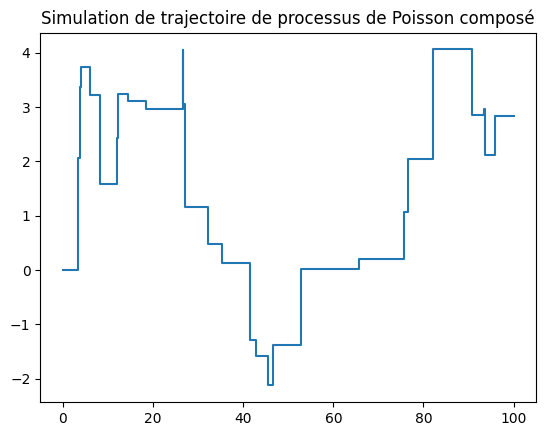

In [21]:
def trajectoire_Poisson_composé_normale(t,l,m,sigma,b): # simule une trajectoire de pP composé de loi de saut normale jusqu'à l'étape t
    k=scipy.stats.poisson.rvs(mu=l*t)
    U=scipy.stats.uniform.rvs(loc=0,scale=t,size=k)
    T=[0]+list(np.sort(U))+[t]
    Y=scipy.stats.norm.rvs(loc=m,scale=sigma, size=k)
    X=np.array([0]+list(np.cumsum(Y))+[np.sum(Y)])
    if b==1:
        plt.plot(T,X,drawstyle='steps-post')
        plt.title('Simulation de trajectoire de processus de Poisson composé')
        plt.show()
    else :
        return(T,X)

trajectoire_Poisson_composé_normale(100,1/3,0,1,1)